# Utah Legislature Bill Outcome Analysis — Primary Subjects (Class-Weighted)
### DS 2500 Final Project — Analysis Methods

This notebook implements the analysis pipeline using **primary subject classification** with **class-weighted models** to address the ~80/20 class imbalance in the floor-sponsored sample.

**Research Questions:**
1. Which aspects of a bill have the most influence over its outcome?
2. Can the outcome of a bill be predicted by analyzing its characteristics?
3. Do economic indicators influence bill outcomes, and does including them improve predictability?

### Why class weights?
In an earlier run, the models achieved ~81% accuracy by simply predicting "Passed" for every bill — the base rate of the majority class. The `Failed` class had precision/recall of 0.00, meaning the models learned nothing about which bills actually fail. By setting `class_weight='balanced'`, we penalize misclassifying failed bills more heavily, forcing the models to learn real distinguishing patterns.

This changes how we evaluate: raw accuracy becomes less meaningful, and **recall on the Failed class** and **ROC-AUC** become the key metrics.

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load primary subject dataset
df_primary = pd.read_csv('df_primary.csv')
print(f"Primary subject dataset: {df_primary.shape[0]} bills")

# Merge party from the multi-subject dataset
df_bills = pd.read_csv('df_bills.csv')[['bill_id', 'session_year', 'party', 'party1']]
df_raw = df_primary.merge(df_bills, on=['bill_id', 'session_year'], how='left')
print(f"After merging party info: {df_raw.shape[0]} bills")

# Filter to only bills that had a floor sponsor
df = df_raw[df_raw['floorspon1'] == 1].copy()
print(f"\nFloor-sponsored bills: {df.shape[0]} ({df.shape[0]/df_raw.shape[0]:.1%} of total)")
print(f"Outcome distribution (passed):")
print(df['passed'].value_counts().to_string())
print(f"Pass rate: {df['passed'].mean():.1%}")
print(f"\nClass imbalance ratio: {df['passed'].value_counts()[1] / df['passed'].value_counts()[0]:.2f}:1")

Primary subject dataset: 8705 bills
After merging party info: 8705 bills

Floor-sponsored bills: 6730 (77.3% of total)
Outcome distribution (passed):
passed
1    5347
0    1383
Pass rate: 79.5%

Class imbalance ratio: 3.87:1


## 1. Exploratory Data Analysis

### 1.1 Define Variable Groups

In [3]:
SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'no_subject', 'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']
ECON_VARS = ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']

df['house_origin'] = (df['originating_chamber'] == 'House').astype(int)
df['subjects_changed_bin'] = df['subjects_changed'].astype(int)

df = df.dropna(subset=['party1']).copy()
df['party1'] = df['party1'].astype(int)

print(f"Analysis sample: {len(df)} bills")

Analysis sample: 6730 bills


### 1.2 Pass Rates by Primary Subject

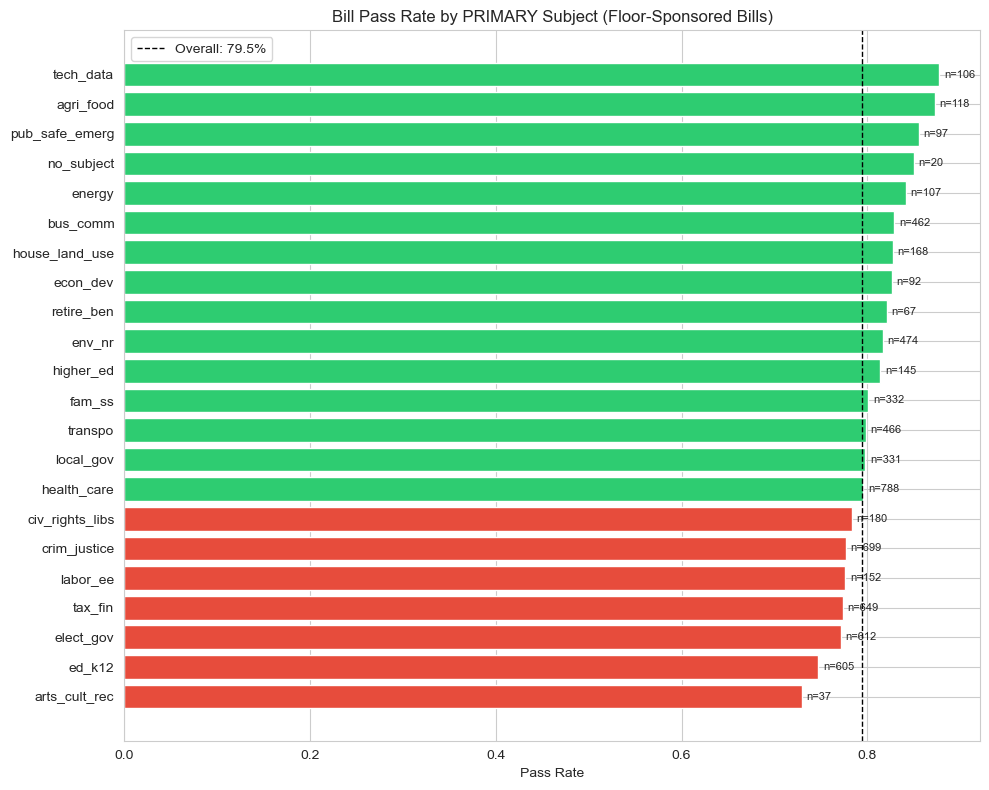

In [4]:
pass_rates = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        pass_rates[col] = {'pass_rate': subset['passed'].mean(), 'count': len(subset)}

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if r > df['passed'].mean() else '#e74c3c' for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors, edgecolor='white')
ax.axvline(df['passed'].mean(), color='black', linestyle='--', linewidth=1, label=f'Overall: {df["passed"].mean():.1%}')
ax.set_xlabel('Pass Rate')
ax.set_title('Bill Pass Rate by PRIMARY Subject (Floor-Sponsored Bills)')
ax.legend()

for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 1.3 Pass Rates by Bill Characteristics & Sponsor Party

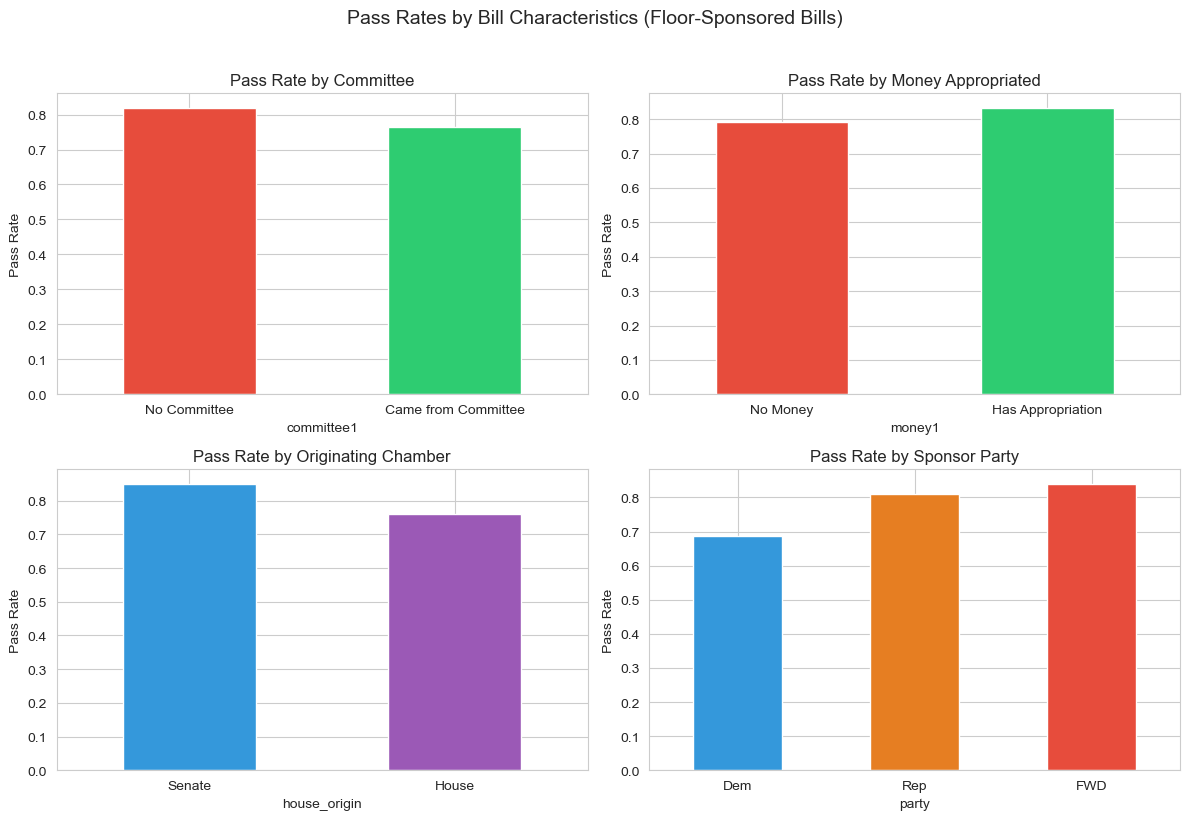

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
df.groupby('committee1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Committee')
ax.set_xticklabels(['No Committee', 'Came from Committee'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[0, 1]
df.groupby('money1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Money Appropriated')
ax.set_xticklabels(['No Money', 'Has Appropriation'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 0]
df.groupby('house_origin')['passed'].mean().plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6'])
ax.set_title('Pass Rate by Originating Chamber')
ax.set_xticklabels(['Senate', 'House'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 1]
party_pass = df.groupby('party')['passed'].mean().sort_values()
party_pass.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22', '#e74c3c'])
ax.set_title('Pass Rate by Sponsor Party')
ax.set_ylabel('Pass Rate')
ax.set_xticklabels(party_pass.index, rotation=0)

plt.suptitle('Pass Rates by Bill Characteristics (Floor-Sponsored Bills)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Primary Subject × Party Pass Rate

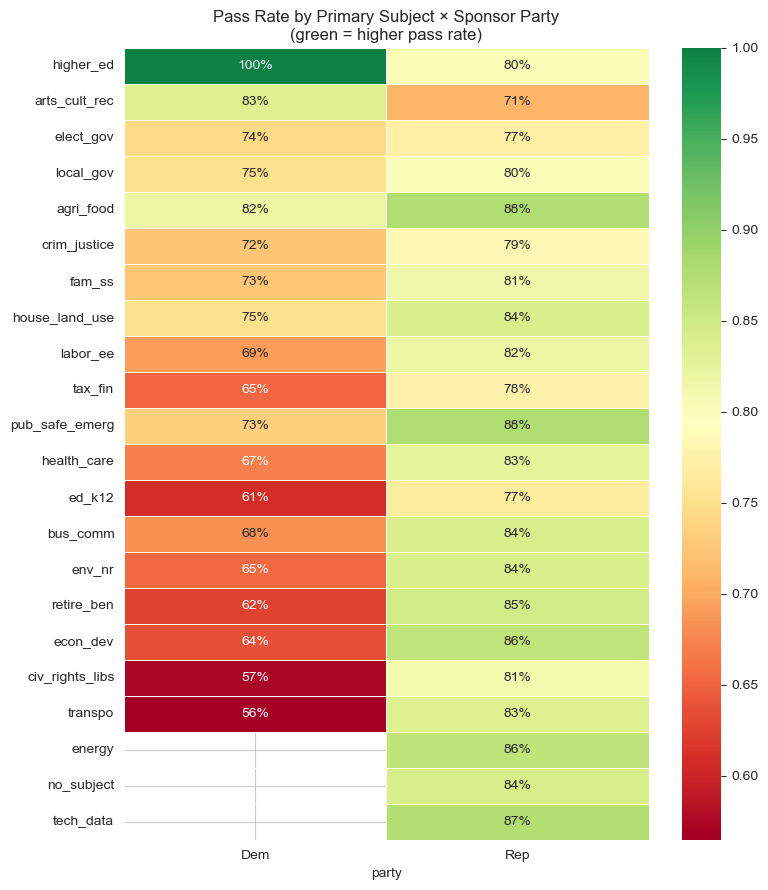

Largest Republican advantage (Rep - Dem pass rate):
subject
transpo            0.269642
civ_rights_libs    0.238698
econ_dev           0.224396
retire_ben         0.222458
env_nr             0.184634

Largest Democrat advantage:
subject
higher_ed       -0.198529
arts_cult_rec   -0.123656
elect_gov        0.026688
local_gov        0.049331
agri_food        0.059177


In [6]:
subject_party = []
for col in SUBJECT_COLS:
    for party in ['Rep', 'Dem']:
        subset = df[(df[col] == 1) & (df['party'] == party)]
        if len(subset) > 5:
            subject_party.append({'subject': col, 'party': party,
                                  'pass_rate': subset['passed'].mean(), 'n': len(subset)})

sp_df = pd.DataFrame(subject_party)
sp_pivot = sp_df.pivot(index='subject', columns='party', values='pass_rate')
sp_pivot['gap'] = sp_pivot['Rep'] - sp_pivot['Dem']
sp_pivot = sp_pivot.sort_values('gap')

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(sp_pivot[['Dem', 'Rep']], annot=True, fmt='.0%', cmap='RdYlGn',
            center=df['passed'].mean(), linewidths=0.5, ax=ax)
ax.set_title('Pass Rate by Primary Subject × Sponsor Party\n(green = higher pass rate)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Largest Republican advantage (Rep - Dem pass rate):")
print(sp_pivot['gap'].sort_values(ascending=False).head(5).to_string())
print("\nLargest Democrat advantage:")
print(sp_pivot['gap'].sort_values().head(5).to_string())

### 1.5 Correlation Matrix

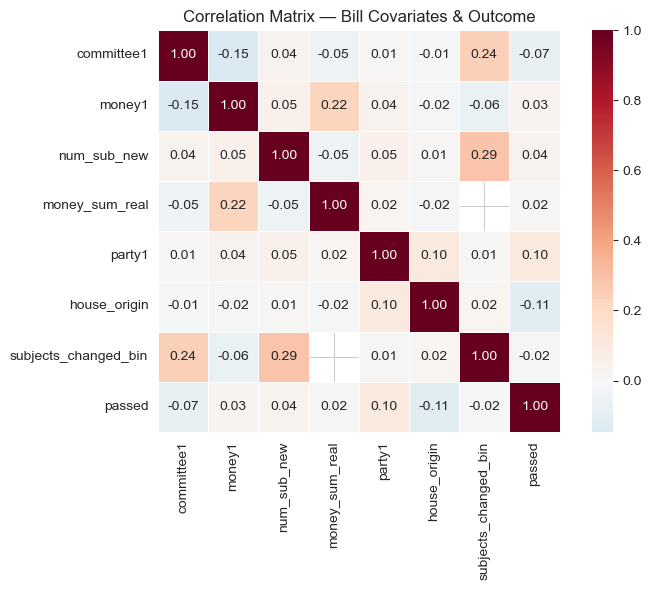

In [7]:
corr_cols = BILL_COVARIATES + ['house_origin', 'subjects_changed_bin', 'passed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Bill Covariates & Outcome')
plt.tight_layout()
plt.show()

## 2. Predictive Modeling — Logistic Regression (Class-Weighted)

All logistic regression models now use `class_weight='balanced'` to address the ~80/20 imbalance. This makes misclassifying failed bills cost ~4× as much as misclassifying passed bills during training.

**Metrics we care about now:**
- **ROC-AUC** — overall discrimination ability (range 0.5–1.0, independent of class balance)
- **Failed-class recall** — what % of bills that actually failed did we correctly identify?
- **Failed-class precision** — of bills we predicted would fail, what % actually did?
- **Balanced accuracy** — average of recall across both classes

Raw accuracy is deprioritized because it's dominated by the majority class.

In [8]:
X_full_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']
y_full = df['passed'].copy()

df_econ = df.dropna(subset=ECON_VARS).copy()
print(f"Analysis sample (floor-sponsored): {len(df)} bills")
print(f"With ACS data (2016-2023): {len(df_econ)} bills")
print(f"Pass rate in ACS subset: {df_econ['passed'].mean():.1%}")

y_econ = df_econ['passed'].copy()

X1 = df_econ[X_full_cols].copy()
X2_cols = X_full_cols + ECON_VARS
X2 = df_econ[X2_cols].copy()

interaction_subjects = ['health_care', 'fam_ss', 'ed_k12', 'crim_justice', 'tax_fin']
X3 = X2.copy()
for econ in ECON_VARS:
    for subj in interaction_subjects:
        X3[f'{econ}_x_{subj}'] = X3[econ] * X3[subj]
for econ in ECON_VARS:
    X3[f'{econ}_x_party1'] = X3[econ] * X3['party1']

print(f"\nFeature counts: Model 1={X1.shape[1]}, Model 2={X2.shape[1]}, Model 3={X3.shape[1]}")

Analysis sample (floor-sponsored): 6730 bills
With ACS data (2016-2023): 5312 bills
Pass rate in ACS subset: 81.2%

Feature counts: Model 1=29, Model 2=33, Model 3=57


In [9]:
# ── Cross-validated model comparison with balanced class weights ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

scoring = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'f1_failed': 'f1',  # f1 for the positive class by default — we want for class 0
    'roc_auc': 'roc_auc',
    'recall_passed': 'recall',
    'precision_passed': 'precision'
}

# We'll compute recall/precision for Failed class manually via confusion from each fold
from sklearn.metrics import make_scorer, recall_score, precision_score
scoring_failed = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'recall_failed': make_scorer(recall_score, pos_label=0),
    'precision_failed': make_scorer(precision_score, pos_label=0, zero_division=0),
    'recall_passed': make_scorer(recall_score, pos_label=1),
}

results = {}
models_dict = {'Model 1: Bill Only': X1, 'Model 2: Bill + ACS': X2, 'Model 3: Bill + ACS + Interactions': X3}

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

    cv_results = cross_validate(lr, X_scaled, y_econ, cv=cv, scoring=scoring_failed)

    results[name] = {
        'Accuracy': f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        'Balanced Acc': f"{cv_results['test_balanced_acc'].mean():.3f} ± {cv_results['test_balanced_acc'].std():.3f}",
        'ROC-AUC': f"{cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}",
        'Failed Recall': f"{cv_results['test_recall_failed'].mean():.3f} ± {cv_results['test_recall_failed'].std():.3f}",
        'Failed Precision': f"{cv_results['test_precision_failed'].mean():.3f} ± {cv_results['test_precision_failed'].std():.3f}",
        'Passed Recall': f"{cv_results['test_recall_passed'].mean():.3f} ± {cv_results['test_recall_passed'].std():.3f}",
        '_auc': cv_results['test_roc_auc'].mean(),
        '_bal_acc': cv_results['test_balanced_acc'].mean(),
    }

results_df = pd.DataFrame(results).T[['Accuracy', 'Balanced Acc', 'ROC-AUC',
                                       'Failed Recall', 'Failed Precision', 'Passed Recall']]
print("5-Fold Stratified Cross-Validation (Class-Weighted Logistic Regression)")
print("=" * 95)
print(results_df.to_string())

5-Fold Stratified Cross-Validation (Class-Weighted Logistic Regression)
                                         Accuracy   Balanced Acc        ROC-AUC  Failed Recall Failed Precision  Passed Recall
Model 1: Bill Only                  0.559 ± 0.022  0.580 ± 0.030  0.611 ± 0.035  0.615 ± 0.046    0.239 ± 0.019  0.545 ± 0.020
Model 2: Bill + ACS                 0.569 ± 0.018  0.591 ± 0.025  0.612 ± 0.037  0.626 ± 0.041    0.246 ± 0.016  0.555 ± 0.017
Model 3: Bill + ACS + Interactions  0.590 ± 0.025  0.590 ± 0.019  0.618 ± 0.028  0.591 ± 0.017    0.251 ± 0.016  0.590 ± 0.029


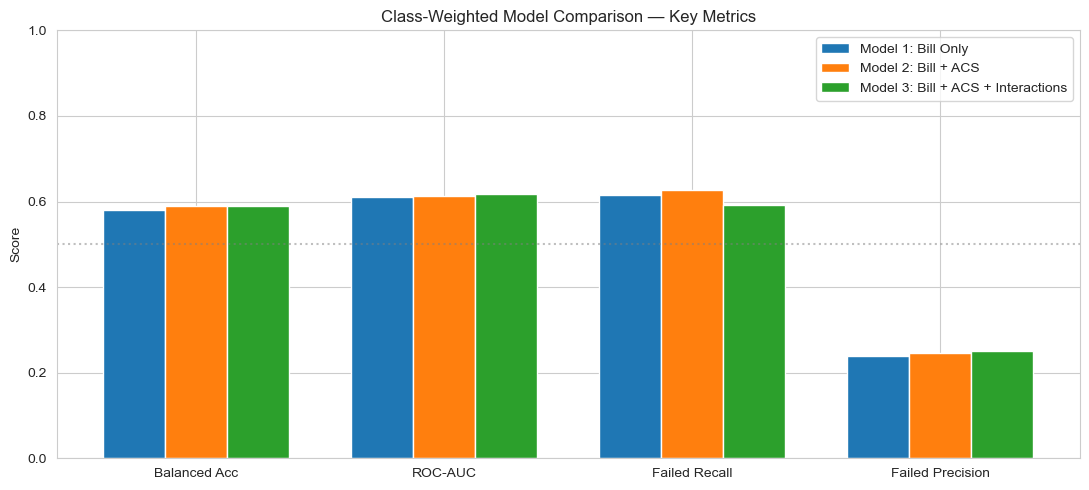

In [10]:
# ── Visualize model comparison focused on meaningful metrics ──
fig, ax = plt.subplots(figsize=(11, 5))

metric_keys = ['_bal_acc', '_auc']
labels = ['Balanced Accuracy', 'ROC-AUC']
model_names = list(results.keys())

# Also add Failed Recall and Precision as numerics for viz
for name in model_names:
    cv_res_raw = cross_validate(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        scaler.fit_transform(models_dict[name]), y_econ, cv=cv, scoring=scoring_failed
    )
    results[name]['_fail_rec'] = cv_res_raw['test_recall_failed'].mean()
    results[name]['_fail_prec'] = cv_res_raw['test_precision_failed'].mean()

metric_keys = ['_bal_acc', '_auc', '_fail_rec', '_fail_prec']
labels = ['Balanced Acc', 'ROC-AUC', 'Failed Recall', 'Failed Precision']

x = np.arange(len(labels))
width = 0.25

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_keys]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_ylabel('Score')
ax.set_title('Class-Weighted Model Comparison — Key Metrics')
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
plt.tight_layout()
plt.show()

### 2.1 Logistic Regression Coefficients (Best Model)

Best model by AUC: Model 3: Bill + ACS + Interactions


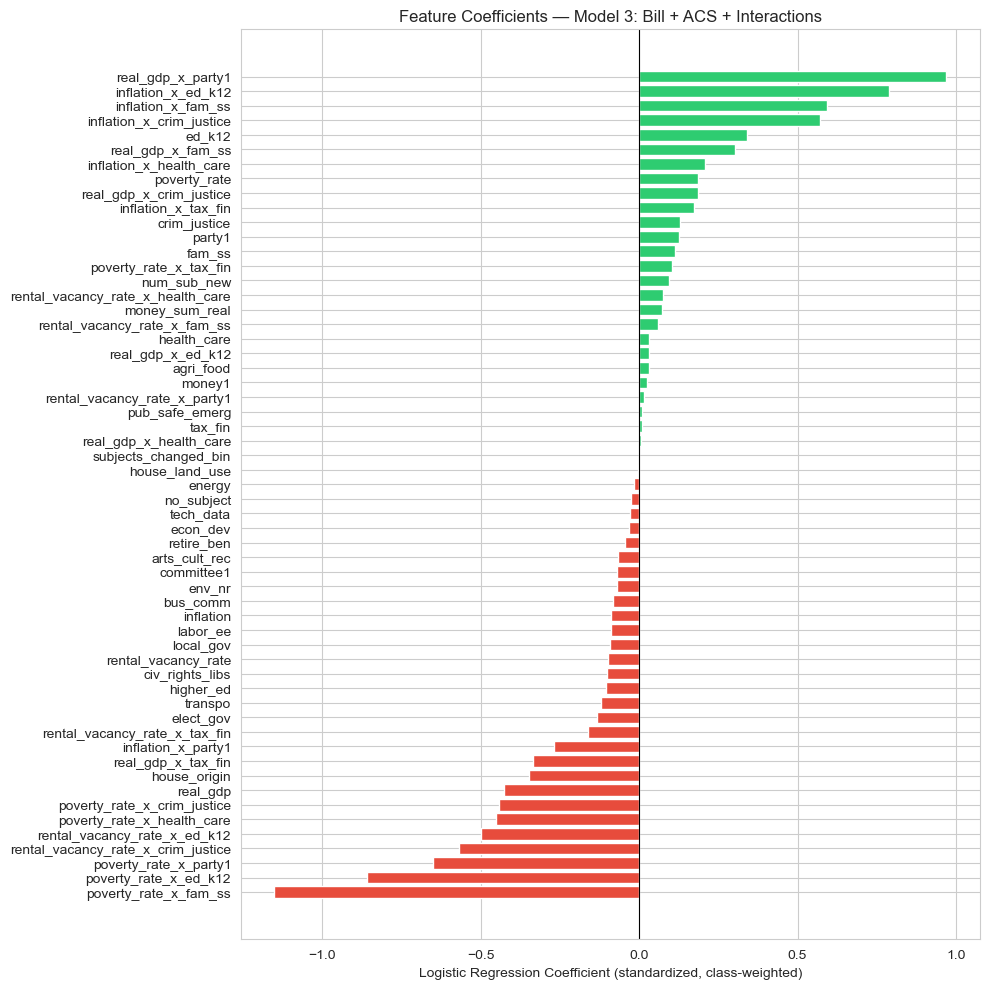


Top 10 positive predictors of passage:
                 Feature  Coefficient  Odds Ratio
     inflation_x_tax_fin     0.172235    1.187957
 real_gdp_x_crim_justice     0.184548    1.202674
            poverty_rate     0.184611    1.202751
 inflation_x_health_care     0.206738    1.229660
       real_gdp_x_fam_ss     0.301686    1.352136
                  ed_k12     0.339581    1.404359
inflation_x_crim_justice     0.570378    1.768935
      inflation_x_fam_ss     0.593610    1.810513
      inflation_x_ed_k12     0.788507    2.200109
       real_gdp_x_party1     0.970041    2.638053

Top 10 negative predictors of passage:
                           Feature  Coefficient  Odds Ratio
             poverty_rate_x_fam_ss    -1.151571    0.316140
             poverty_rate_x_ed_k12    -0.859567    0.423345
             poverty_rate_x_party1    -0.650506    0.521782
rental_vacancy_rate_x_crim_justice    -0.568413    0.566424
      rental_vacancy_rate_x_ed_k12    -0.500204    0.606407
        po

In [11]:
best_name = max(results, key=lambda k: results[k]['_auc'])
best_X = models_dict[best_name]
print(f"Best model by AUC: {best_name}")

X_scaled = scaler.fit_transform(best_X)
lr_best = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_best.fit(X_scaled, y_econ)

coef_df = pd.DataFrame({
    'Feature': best_X.columns,
    'Coefficient': lr_best.coef_[0],
    'Odds Ratio': np.exp(lr_best.coef_[0])
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (standardized, class-weighted)')
ax.set_title(f'Feature Coefficients — {best_name}')
plt.tight_layout()
plt.show()

print("\nTop 10 positive predictors of passage:")
print(coef_df.tail(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))
print("\nTop 10 negative predictors of passage:")
print(coef_df.head(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))

### 2.2 Confusion Matrix — Best Logistic Regression Model

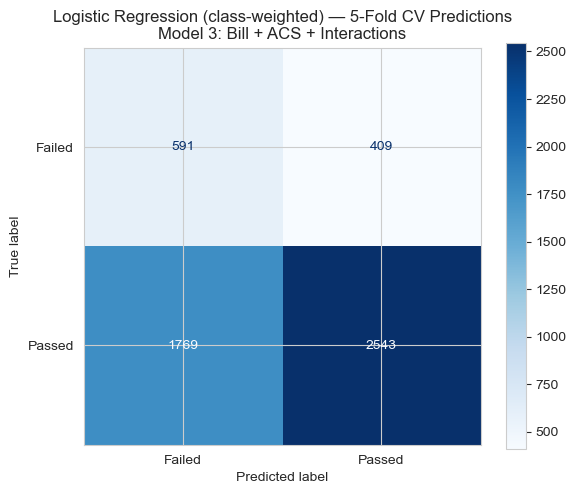

              precision    recall  f1-score   support

      Failed       0.25      0.59      0.35      1000
      Passed       0.86      0.59      0.70      4312

    accuracy                           0.59      5312
   macro avg       0.56      0.59      0.53      5312
weighted avg       0.75      0.59      0.63      5312



In [12]:
# Show how class weighting actually changed predictions
from sklearn.model_selection import cross_val_predict
y_pred_lr = cross_val_predict(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    scaler.fit_transform(best_X), y_econ, cv=cv
)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_econ, y_pred_lr,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Blues', ax=ax)
ax.set_title(f'Logistic Regression (class-weighted) — 5-Fold CV Predictions\n{best_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_econ, y_pred_lr, target_names=['Failed', 'Passed']))

### 2.3 ROC Curve

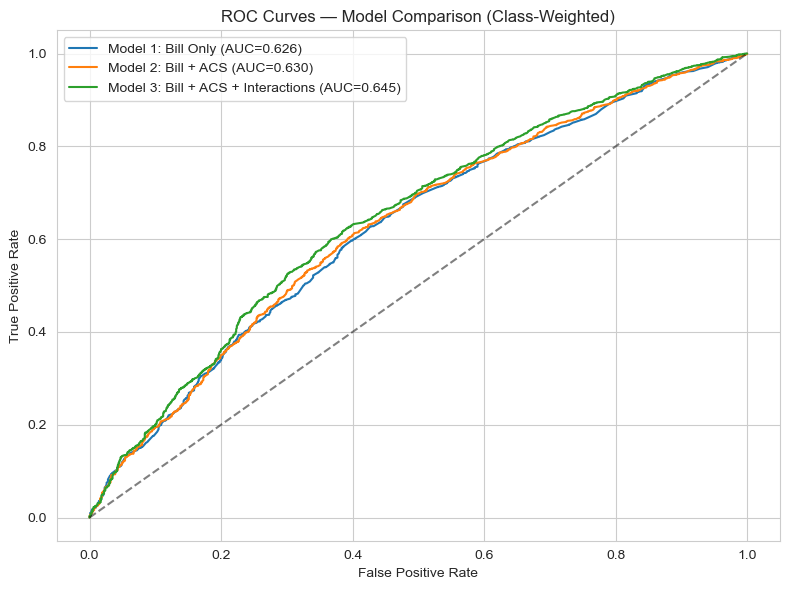

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_scaled, y_econ)
    y_prob = lr.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_econ, y_prob)
    auc_val = roc_auc_score(y_econ, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison (Class-Weighted)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Classification Trees & Random Forest (Class-Weighted)

Both the decision tree and random forest use `class_weight='balanced'` to force the models to actually learn patterns that distinguish failed bills from passed bills.

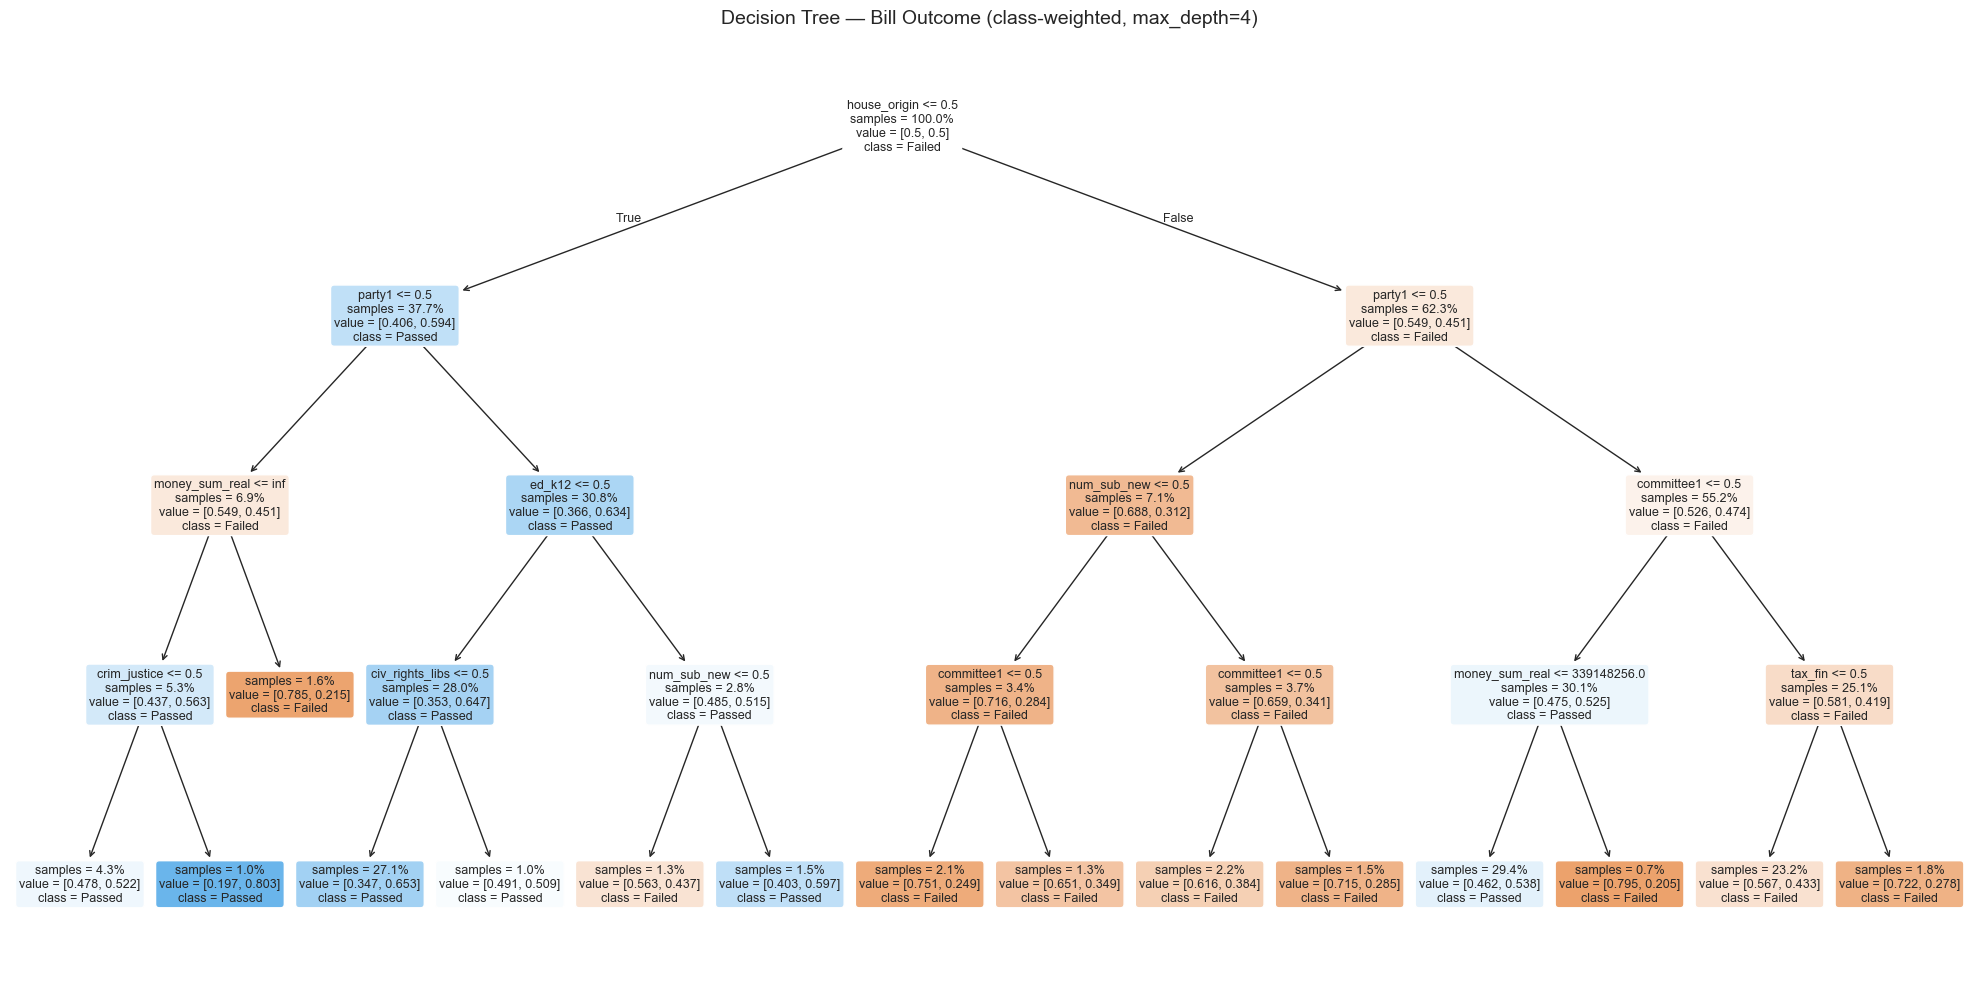

Decision Tree Balanced Accuracy: 0.518 ± 0.033
Decision Tree ROC-AUC: 0.551 ± 0.036


In [14]:
feature_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42,
                             class_weight='balanced')
dt.fit(df[feature_cols], y_full)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_cols, class_names=['Failed', 'Passed'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          proportion=True, impurity=False)
ax.set_title('Decision Tree — Bill Outcome (class-weighted, max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()

dt_cv_bal = cross_val_score(dt, df[feature_cols], y_full, cv=5, scoring='balanced_accuracy')
dt_cv_auc = cross_val_score(dt, df[feature_cols], y_full, cv=5, scoring='roc_auc')
print(f"Decision Tree Balanced Accuracy: {dt_cv_bal.mean():.3f} ± {dt_cv_bal.std():.3f}")
print(f"Decision Tree ROC-AUC: {dt_cv_auc.mean():.3f} ± {dt_cv_auc.std():.3f}")

### 3.1 Random Forest — CV Performance & Feature Importance

Random Forest 5-Fold CV (class-weighted):
  Accuracy:         0.511 ± 0.173
  Balanced Acc:     0.550 ± 0.033
  ROC-AUC:          0.570 ± 0.058
  Failed Recall:    0.615 ± 0.266
  Failed Precision: 0.251 ± 0.035
  Passed Recall:    0.484 ± 0.285


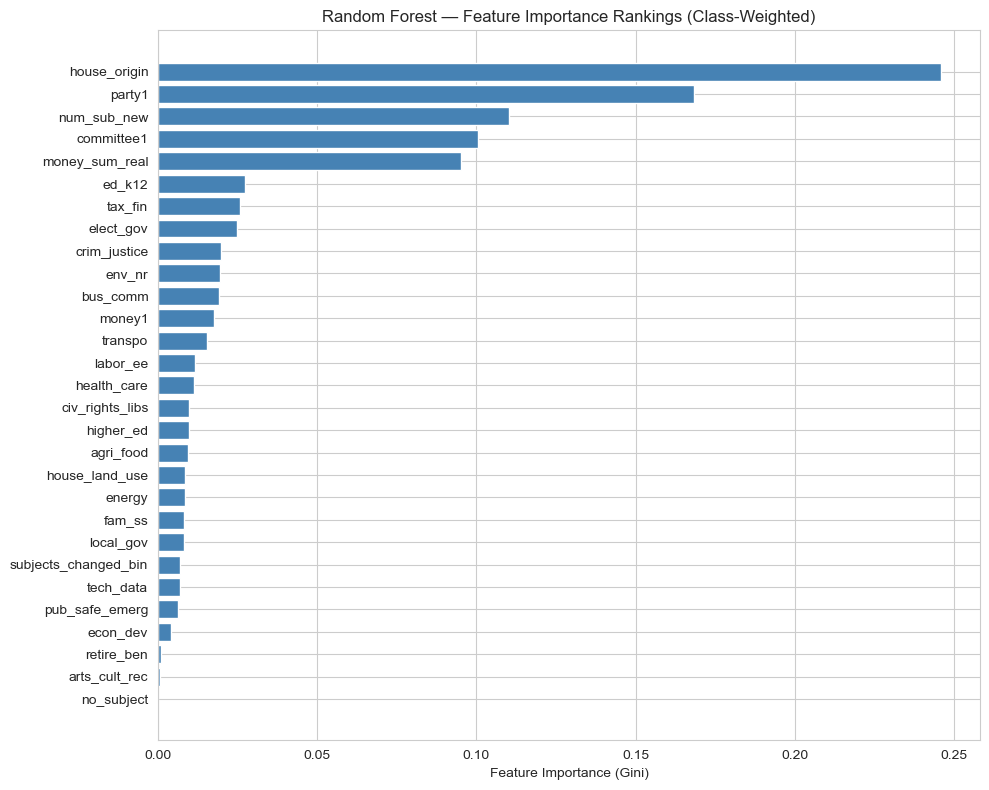


Top 10 most important features:
       Feature  Importance
        env_nr    0.019503
  crim_justice    0.019908
     elect_gov    0.024774
       tax_fin    0.025710
        ed_k12    0.027175
money_sum_real    0.095091
    committee1    0.100341
   num_sub_new    0.110386
        party1    0.168261
  house_origin    0.245903


In [15]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(df[feature_cols], y_full)

cv_rf = cross_validate(rf, df[feature_cols], y_full, cv=5, scoring=scoring_failed)
print(f"Random Forest 5-Fold CV (class-weighted):")
print(f"  Accuracy:         {cv_rf['test_accuracy'].mean():.3f} ± {cv_rf['test_accuracy'].std():.3f}")
print(f"  Balanced Acc:     {cv_rf['test_balanced_acc'].mean():.3f} ± {cv_rf['test_balanced_acc'].std():.3f}")
print(f"  ROC-AUC:          {cv_rf['test_roc_auc'].mean():.3f} ± {cv_rf['test_roc_auc'].std():.3f}")
print(f"  Failed Recall:    {cv_rf['test_recall_failed'].mean():.3f} ± {cv_rf['test_recall_failed'].std():.3f}")
print(f"  Failed Precision: {cv_rf['test_precision_failed'].mean():.3f} ± {cv_rf['test_precision_failed'].std():.3f}")
print(f"  Passed Recall:    {cv_rf['test_recall_passed'].mean():.3f} ± {cv_rf['test_recall_passed'].std():.3f}")

imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance Rankings (Class-Weighted)')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(imp_df.tail(10)[['Feature', 'Importance']].to_string(index=False))

### 3.2 Random Forest — Confusion Matrix (CV Predictions)

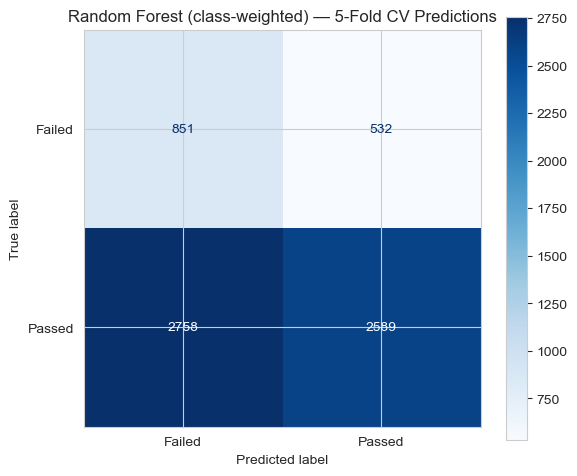

              precision    recall  f1-score   support

      Failed       0.24      0.62      0.34      1383
      Passed       0.83      0.48      0.61      5347

    accuracy                           0.51      6730
   macro avg       0.53      0.55      0.48      6730
weighted avg       0.71      0.51      0.56      6730



In [16]:
y_pred_rf = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                           random_state=42, n_jobs=-1, class_weight='balanced'),
    df[feature_cols], y_full, cv=5
)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_full, y_pred_rf,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Blues', ax=ax)
ax.set_title('Random Forest (class-weighted) — 5-Fold CV Predictions')
plt.tight_layout()
plt.show()

print(classification_report(y_full, y_pred_rf, target_names=['Failed', 'Passed']))

## 4. Bonus — Location Stage

`location_stage` (0–3) captures *how far* a bill got. With primary subjects, we can see cleanly which domains die early.

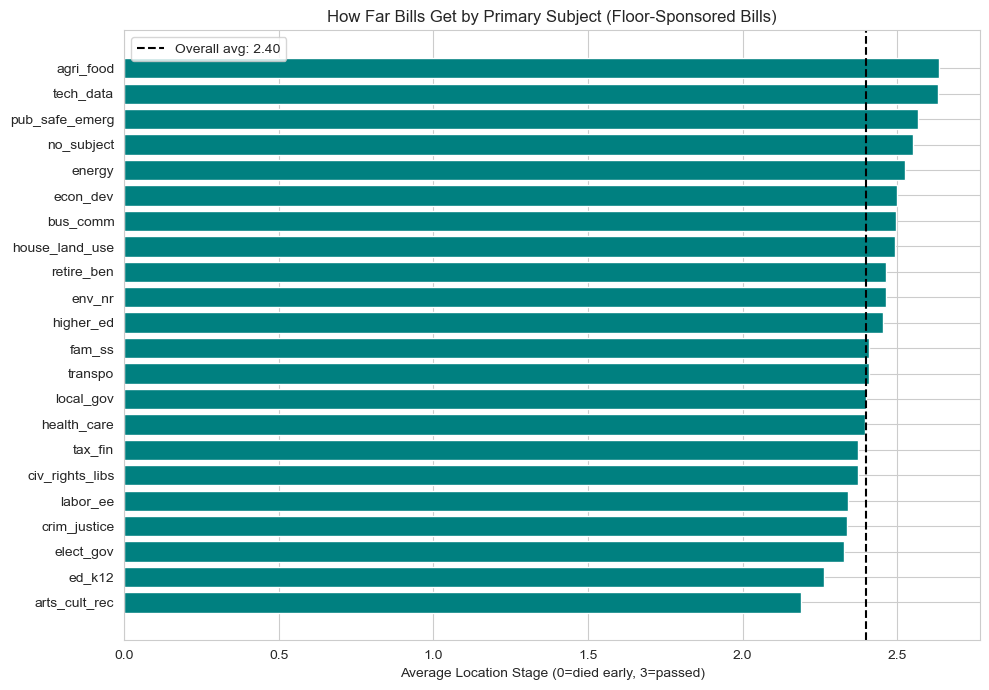

In [17]:
stage_by_subj = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 10:
        stage_by_subj[col] = subset['location_stage'].mean()

stage_df = pd.Series(stage_by_subj).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(stage_df.index, stage_df.values, color='teal', edgecolor='white')
ax.axvline(df['location_stage'].mean(), color='black', linestyle='--',
           label=f'Overall avg: {df["location_stage"].mean():.2f}')
ax.set_xlabel('Average Location Stage (0=died early, 3=passed)')
ax.set_title('How Far Bills Get by Primary Subject (Floor-Sponsored Bills)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Location Stage by Party

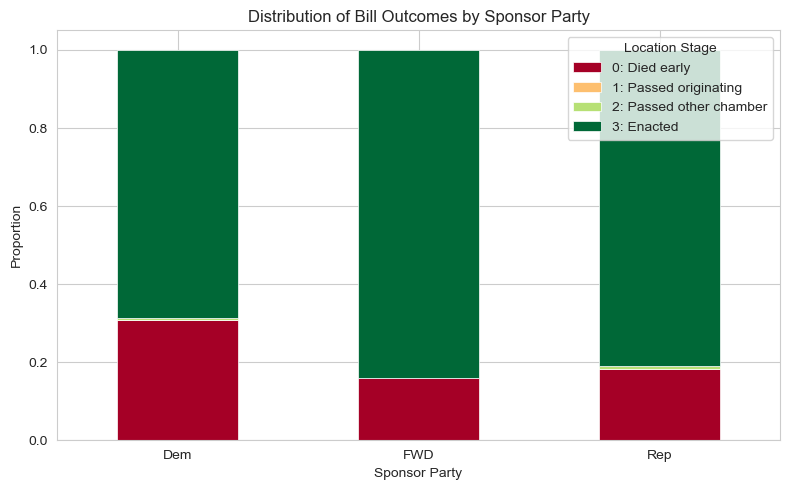

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
stage_party = df.groupby('party')['location_stage'].value_counts(normalize=True).unstack(fill_value=0)
stage_party.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn',
                 edgecolor='white', linewidth=0.5)
ax.set_title('Distribution of Bill Outcomes by Sponsor Party')
ax.set_xlabel('Sponsor Party')
ax.set_ylabel('Proportion')
ax.legend(title='Location Stage', labels=['0: Died early', '1: Passed originating', '2: Passed other chamber', '3: Enacted'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Summary

### What Class Weighting Changes
- **Before**: models predicted "Passed" for every bill. Accuracy was 81% (just the base rate). Failed-class recall was 0.00 — the models learned nothing about failure.
- **After**: models are forced to distinguish failed from passed bills. Accuracy may drop, but **balanced accuracy, ROC-AUC, and Failed recall** become meaningful.

### How to Interpret the Results
- **ROC-AUC around 0.6–0.7**: models are learning real signal, but outcome is still hard to predict from these features alone.
- **ROC-AUC around 0.5**: models are no better than random.
- **Failed recall**: what fraction of bills that actually failed did we correctly flag?
- **Failed precision**: when we predicted failure, how often were we right?

### Key Findings to Report
- Best logistic regression model and its balanced accuracy / AUC / Failed recall
- Random forest balanced accuracy and feature importance ranking
- Which primary subjects and bill characteristics most predict failure (from the coefficient plot and feature importance)
- Partisan patterns in the subject × party heatmap

### Limitations
- Even with class weighting, predicting bill failure is fundamentally hard — many of the drivers (political dynamics, timing, lobbying) aren't in this dataset.
- `party1` groups Dem + FWD together due to small FWD sample size.
- ACS data missing for 2024–2026.
- Cosponsor data only available from 2023 onward.